In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , classification_report
import warnings
warnings.filterwarnings("ignore")

Read Data

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("naeem41/cicids2017-dataset")

# print("Path to dataset files:", path)

In [3]:
# import os

# for root, dirs, files in os.walk(path):
#     for file in files:
#         print(os.path.join(root, file))

In [4]:
df_data = pd.read_csv("combinenew.csv")
df_data.shape

(2830744, 79)

Show Data

In [5]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


Information About Data And Describe Data

In [6]:
df_data.info(show_counts=True)
# Target => Label => Str
# Destination Port => Object
# Remaining Data => Float


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             2830744 non-null  object 
 1    Flow Duration                2830743 non-null  float64
 2    Total Fwd Packets            2830743 non-null  float64
 3    Total Backward Packets       2830743 non-null  float64
 4   Total Length of Fwd Packets   2830743 non-null  float64
 5    Total Length of Bwd Packets  2830743 non-null  float64
 6    Fwd Packet Length Max        2830743 non-null  float64
 7    Fwd Packet Length Min        2830743 non-null  float64
 8    Fwd Packet Length Mean       2830743 non-null  float64
 9    Fwd Packet Length Std        2830743 non-null  float64
 10  Bwd Packet Length Max         2830743 non-null  float64
 11   Bwd Packet Length Min        2830743 non-null  float64
 12   Bwd Packet Length Mean     

In [7]:
pd.set_option('display.float_format', lambda x: '%.2f' % x) # So We Can See The Data Clearly.
df_data.describe() # Data Need Scaling

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,...,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00
mean,14785663.93,9.36,10.39,549.30,16162.64,207.60,18.71,58.20,68.91,870.85,...,5.42,-2741.69,81551.32,41134.12,153182.52,58295.82,8316036.63,503843.95,8695751.98,7920031.01
std,33653744.09,749.67,997.39,9993.59,2263088.05,717.18,60.34,186.09,281.19,1946.37,...,636.43,1084989.38,648599.94,393381.52,1025824.97,577092.28,23630078.58,4602984.48,24366888.33,23363418.93
min,-13.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,-536870661.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,155.00,2.00,1.00,12.00,0.00,6.00,0.00,6.00,0.00,0.00,...,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,31316.00,2.00,2.00,62.00,123.00,37.00,2.00,34.00,0.00,79.00,...,1.00,24.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,3204828.50,5.00,4.00,187.00,482.00,81.00,36.00,50.00,26.16,280.00,...,2.00,32.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,119999998.00,219759.00,291922.00,12900000.00,655453030.00,24820.00,2325.00,5940.86,7125.60,19530.00,...,213557.00,138.00,110000000.00,74200000.00,110000000.00,110000000.00,120000000.00,76900000.00,120000000.00,120000000.00


Check About Dublicates

In [8]:
df_data.duplicated().sum()

np.int64(330406)

There is 330406 duplicated we will remove

In [9]:
df_data.drop_duplicates(inplace=True) # Drop Duplicates

df_data.duplicated().sum() # Check Again

np.int64(0)

In [10]:
df_data.shape # The Shape Data After Drop Duplicates

(2500338, 79)

Check Null Values

In [11]:
df_data.replace([np.inf, -np.inf], np.nan, inplace=True)
df_data.replace(['?', 'unknown', 'Unknown', 'UNKNOWN', 'None', 'none', ' '], np.nan, inplace=True)
print(df_data.isnull().sum().to_string())

 Destination Port                  0
 Flow Duration                     1
 Total Fwd Packets                 1
 Total Backward Packets            1
Total Length of Fwd Packets        1
 Total Length of Bwd Packets       1
 Fwd Packet Length Max             1
 Fwd Packet Length Min             1
 Fwd Packet Length Mean            1
 Fwd Packet Length Std             1
Bwd Packet Length Max              1
 Bwd Packet Length Min             1
 Bwd Packet Length Mean            1
 Bwd Packet Length Std             1
Flow Bytes/s                    1542
 Flow Packets/s                 1538
 Flow IAT Mean                     1
 Flow IAT Std                      1
 Flow IAT Max                      1
 Flow IAT Min                      1
Fwd IAT Total                      1
 Fwd IAT Mean                      1
 Fwd IAT Std                       1
 Fwd IAT Max                       1
 Fwd IAT Min                       1
Bwd IAT Total                      1
 Bwd IAT Mean                      1
 

Null Values Is Very Low We Will Drop it

In [12]:
df_data.dropna(inplace=True)
# Check
print(df_data.isnull().sum().to_string())

 Destination Port               0
 Flow Duration                  0
 Total Fwd Packets              0
 Total Backward Packets         0
Total Length of Fwd Packets     0
 Total Length of Bwd Packets    0
 Fwd Packet Length Max          0
 Fwd Packet Length Min          0
 Fwd Packet Length Mean         0
 Fwd Packet Length Std          0
Bwd Packet Length Max           0
 Bwd Packet Length Min          0
 Bwd Packet Length Mean         0
 Bwd Packet Length Std          0
Flow Bytes/s                    0
 Flow Packets/s                 0
 Flow IAT Mean                  0
 Flow IAT Std                   0
 Flow IAT Max                   0
 Flow IAT Min                   0
Fwd IAT Total                   0
 Fwd IAT Mean                   0
 Fwd IAT Std                    0
 Fwd IAT Max                    0
 Fwd IAT Min                    0
Bwd IAT Total                   0
 Bwd IAT Mean                   0
 Bwd IAT Std                    0
 Bwd IAT Max                    0
 Bwd IAT Min  

In [13]:
# Destination Port => object , but we want it to be int.
df_data.columns = df_data.columns.str.strip()
df_data['Destination Port'] = pd.to_numeric(df_data['Destination Port'], errors='coerce')
df_data.dropna(subset=['Destination Port'], inplace=True)
df_data['Destination Port'] = df_data['Destination Port'].astype(int)


df_data.reset_index(drop=True, inplace=True)

print(df_data['Destination Port'].dtype)
print("Shape:", df_data.shape)

int64
Shape: (2498796, 79)


Quick-iteration sample: this keeps every Label's share of the data the same (stratified), just with fewer rows, so the dataset still looks like the full one. Set `SAMPLE_FRACTION = 1.0` before your final run to switch back to the full dataset.

In [ ]:
SAMPLE_FRACTION = 0.25  

df_data = (
    df_data.groupby('Label', group_keys=False)
    .apply(lambda g: g.sample(frac=SAMPLE_FRACTION, random_state=42))
    .reset_index(drop=True)
)

print("Shape after sampling:", df_data.shape)
print(df_data['Label'].value_counts(normalize=True).round(4))

Shape after sampling: (624701, 79)
Label
BENIGN                     0.83
DoS Hulk                   0.07
DDoS                       0.05
PortScan                   0.04
DoS GoldenEye              0.00
FTP-Patator                0.00
DoS slowloris              0.00
DoS Slowhttptest           0.00
SSH-Patator                0.00
Bot                        0.00
Web Attack_Brute Force     0.00
Web Attack_XSS             0.00
Infiltration               0.00
Web Attack_Sql Injection   0.00
Heartbleed                 0.00
Name: proportion, dtype: float64


Remove Zero-Variance Columns

Note: these columns are almost always 0, so they carry no signal. This is a low-variance issue, not data leakage.

In [15]:
df_data.columns = df_data.columns.str.strip()
col_zero = [

    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bytes/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bulk Rate",
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd URG Flags",
    "CWE Flag Count"
]
zero_pct = (df_data[col_zero].replace(0, np.nan).isnull().sum() / len(df_data)) * 100
print(zero_pct)


Fwd Avg Packets/Bulk   100.00
Fwd Avg Bytes/Bulk     100.00
Bwd Avg Packets/Bulk   100.00
Bwd Avg Bytes/Bulk     100.00
Fwd Avg Bulk Rate      100.00
Bwd Avg Bulk Rate      100.00
Bwd PSH Flags          100.00
Bwd URG Flags          100.00
Fwd URG Flags          100.00
CWE Flag Count         100.00
dtype: float64


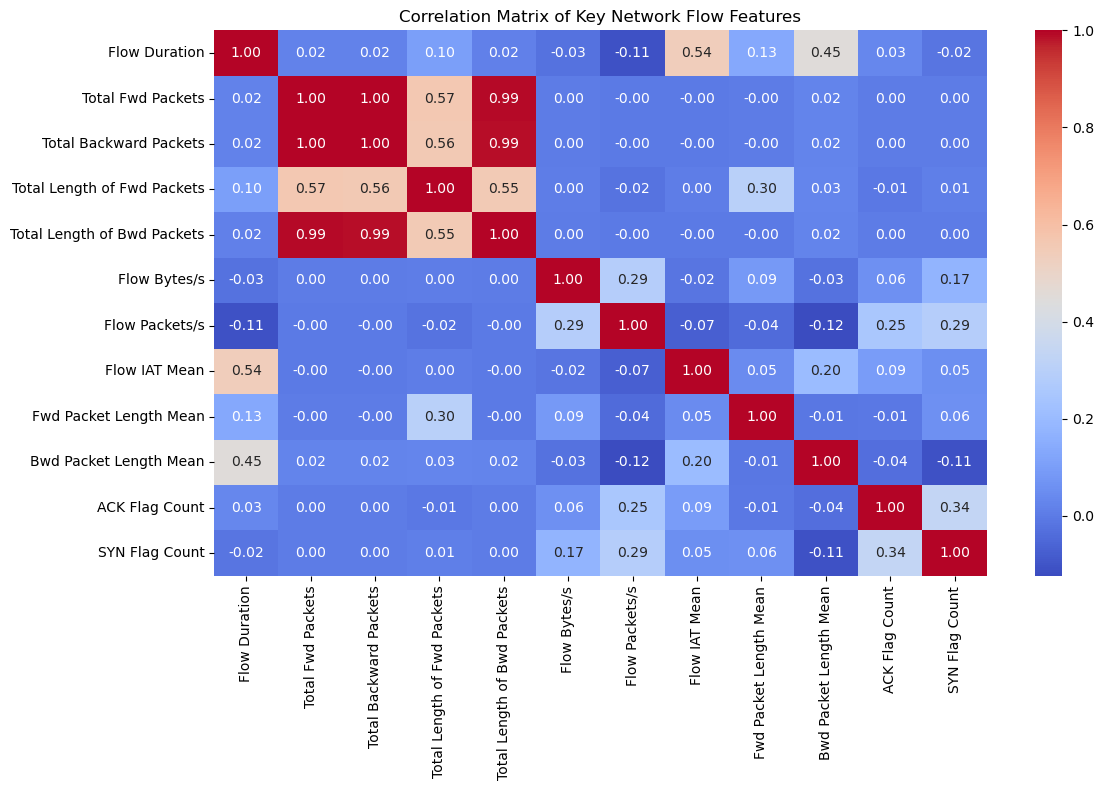

In [16]:
# Check Heatmap Again
key_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'ACK Flag Count', 'SYN Flag Count'
]
plt.figure(figsize=(12, 8))
corr = df_data[key_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Key Network Flow Features")
plt.tight_layout()
plt.show()

In [17]:
df_data.drop(columns=col_zero, inplace=True)
print("Shape:", df_data.shape)

Shape: (624701, 69)


In [18]:
df_data.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',
 'ECE Flag Count',
 'Down/Up Ratio',
 '

In [19]:
non_negative_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'min_seg_size_forward', 'act_data_pkt_fwd',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
non_negative_cols = [c for c in non_negative_cols if c in df_data.columns]

bad_row_mask = (df_data[non_negative_cols] < 0).any(axis=1)
bad_row_mask.sum() #number of invalid negative vals in columns

np.int64(732)

In [20]:
df_data = df_data.loc[~bad_row_mask].reset_index(drop=True)
df_data.shape

(623969, 69)

Check Class Distribution (Label)

In [21]:
label_counts = df_data['Label'].value_counts()
label_percentage = df_data['Label'].value_counts(normalize=True) * 100

distribution = pd.DataFrame({'Count': label_counts, 'Percentage': label_percentage.round(3)})
print(distribution)

                           Count  Percentage
Label                                       
BENIGN                    517580       82.95
DoS Hulk                   43171        6.92
DDoS                       31999        5.13
PortScan                   22674        3.63
DoS GoldenEye               2571        0.41
FTP-Patator                 1482        0.24
DoS slowloris               1346        0.22
DoS Slowhttptest            1307        0.21
SSH-Patator                  805        0.13
Bot                          487        0.08
Web Attack_Brute Force       368        0.06
Web Attack_XSS               163        0.03
Infiltration                   9        0.00
Web Attack_Sql Injection       5        0.00
Heartbleed                     2        0.00


The dataset is highly imbalanced (BENIGN dominates)

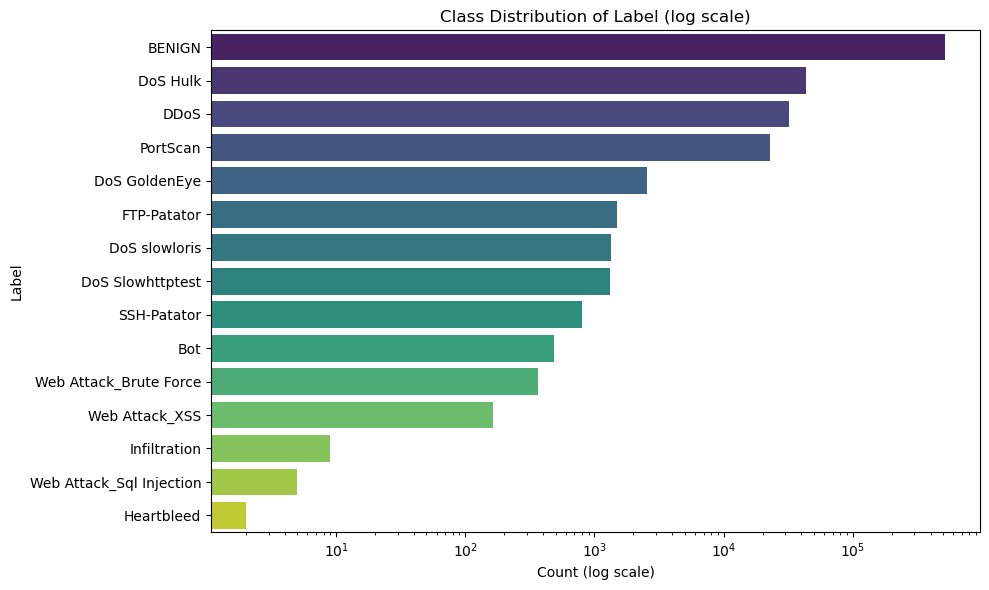

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('Label')
plt.title('Class Distribution of Label (log scale)')
plt.tight_layout()
plt.show()

## EDA

#### Correlation matrix across all numeric features (not just a manual subset)

In [23]:
# numeric_df = df_data.select_dtypes(include=[np.number]).drop(columns=['Destination Port'], errors='ignore')

# full_corr = numeric_df.corr().abs()

# plt.figure(figsize=(20, 16))
# sns.heatmap(full_corr, cmap="coolwarm", cbar=True)
# plt.title("Correlation Matrix - All Numeric Features")
# plt.tight_layout()
# plt.show()

#### Find redundant columns (correlation > 0.95), and check none of them are actually important to the target before dropping

In [24]:
# upper = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))

# threshold = 0.95
# to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

# temp_binary_label = df_data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
# numeric_df_with_target = numeric_df.copy()
# numeric_df_with_target['Binary_Label'] = temp_binary_label

# target_corr = numeric_df_with_target[to_drop + ['Binary_Label']].corr()['Binary_Label']

# print(f"Number of columns to drop: {len(to_drop)}")
# print("\nCorrelation of dropped columns with target:")
# print(target_corr.sort_values(ascending=False))

#### Drop the redundant columns

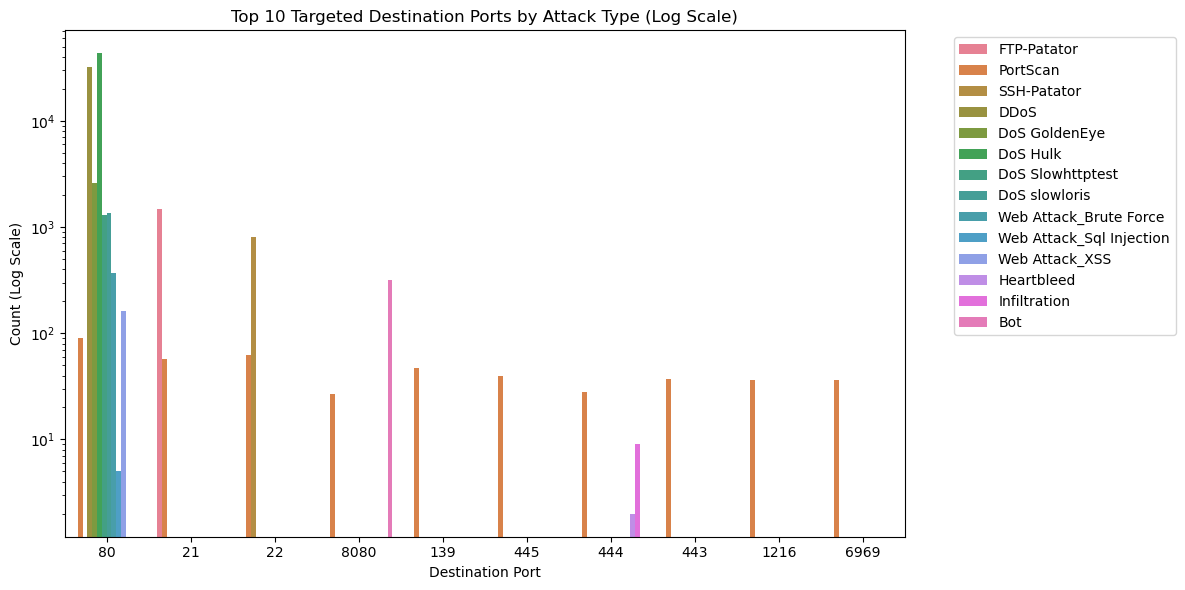

In [25]:
attack_df = df_data[df_data['Label'] != 'BENIGN']
top_ports = attack_df['Destination Port'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=attack_df[attack_df['Destination Port'].isin(top_ports)],
    x='Destination Port',
    hue='Label',
    order=top_ports
)
plt.yscale('log')
plt.title('Top 10 Targeted Destination Ports by Attack Type (Log Scale)')
plt.xlabel('Destination Port')
plt.ylabel('Count (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

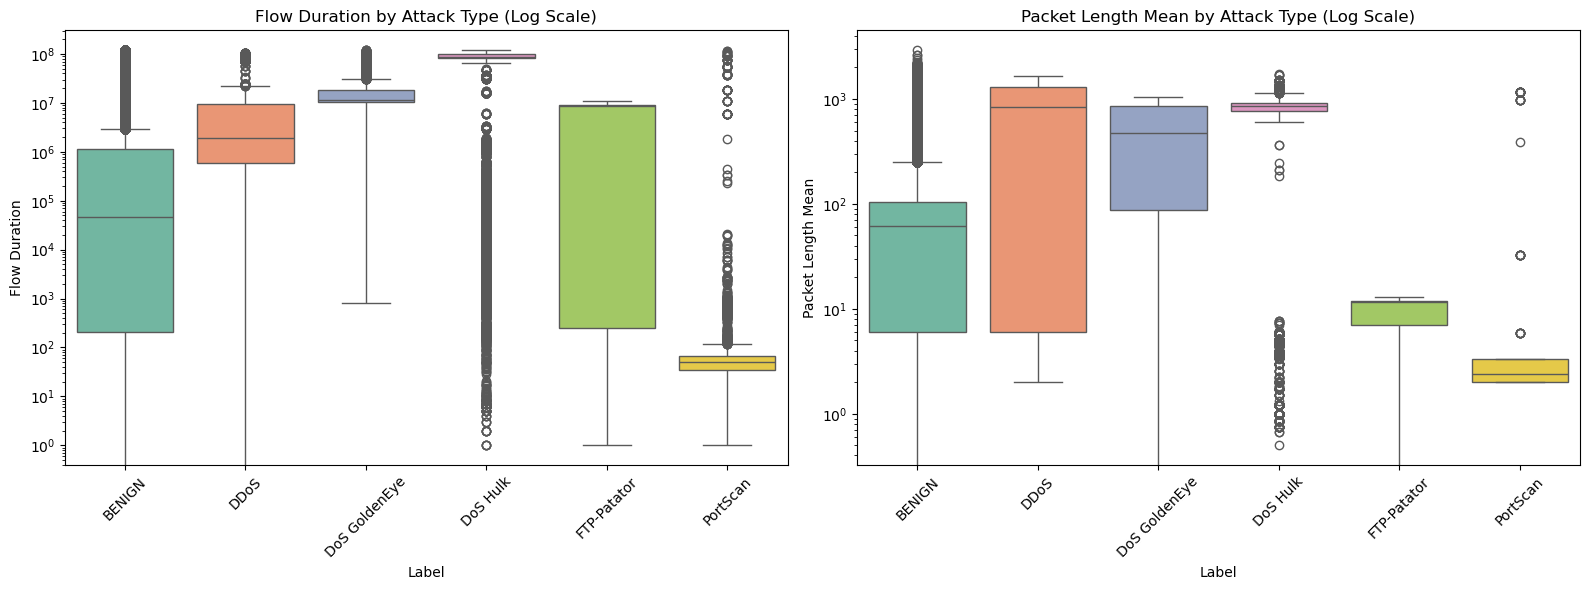

In [26]:
top_labels = df_data['Label'].value_counts().head(6).index
df_subset = df_data[df_data['Label'].isin(top_labels)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], data=df_subset, x='Label', y='Flow Duration', palette='Set2')
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration by Attack Type (Log Scale)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(ax=axes[1], data=df_subset, x='Label', y='Packet Length Mean', palette='Set2')
axes[1].set_yscale('log')
axes[1].set_title('Packet Length Mean by Attack Type (Log Scale)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

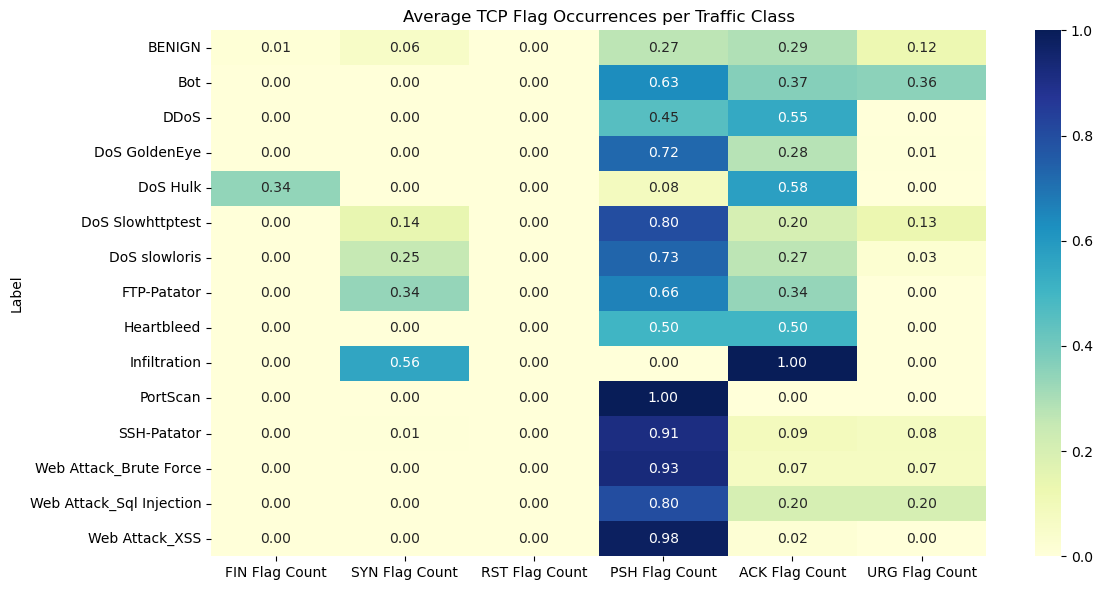

In [27]:
flag_cols = ['FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count']
flag_summary = df_data.groupby('Label')[flag_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(flag_summary, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average TCP Flag Occurrences per Traffic Class")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

making dest ports into categories

In [28]:
def categorize_port(port):
    if port <= 1023:
        return 'Well_Known'
    elif port <= 49151:
        return 'Registered'
    else:
        return 'Dynamic'

df_data['Port_Category'] = df_data['Destination Port'].apply(categorize_port)
df_data = pd.get_dummies(df_data, columns=['Port_Category'], drop_first=True)
df_data.drop(columns=['Destination Port'], inplace=True)

Encode categorical labels to numeric values

In [29]:
le = LabelEncoder()
df_data['Label_Encoded'] = le.fit_transform(df_data['Label'])


Map to Binary (0: BENIGN, 1: ATTACK)

In [30]:
df_data['Binary_Label'] = df_data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

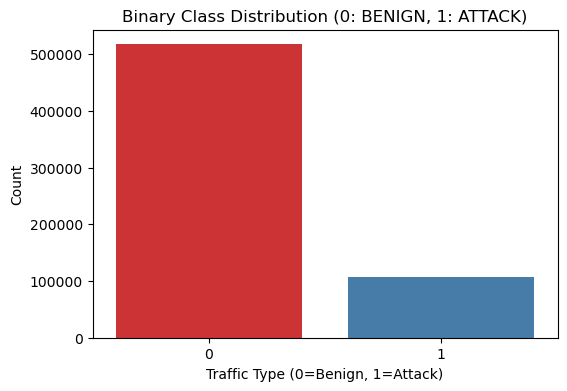

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_data, x='Binary_Label', palette='Set1')
plt.title('Binary Class Distribution (0: BENIGN, 1: ATTACK)')
plt.xlabel('Traffic Type (0=Benign, 1=Attack)')
plt.ylabel('Count')
plt.show()

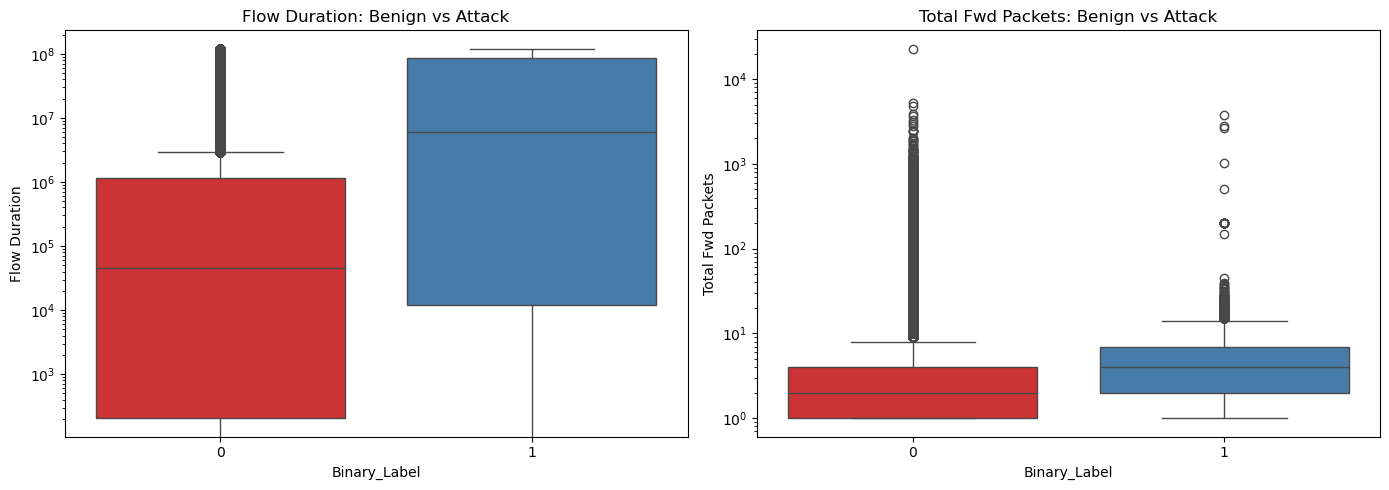

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], data=df_data, x='Binary_Label', y='Flow Duration', palette='Set1')
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration: Benign vs Attack')

sns.boxplot(ax=axes[1], data=df_data, x='Binary_Label', y='Total Fwd Packets', palette='Set1')
axes[1].set_yscale('log')
axes[1].set_title('Total Fwd Packets: Benign vs Attack')

plt.tight_layout()
plt.show()

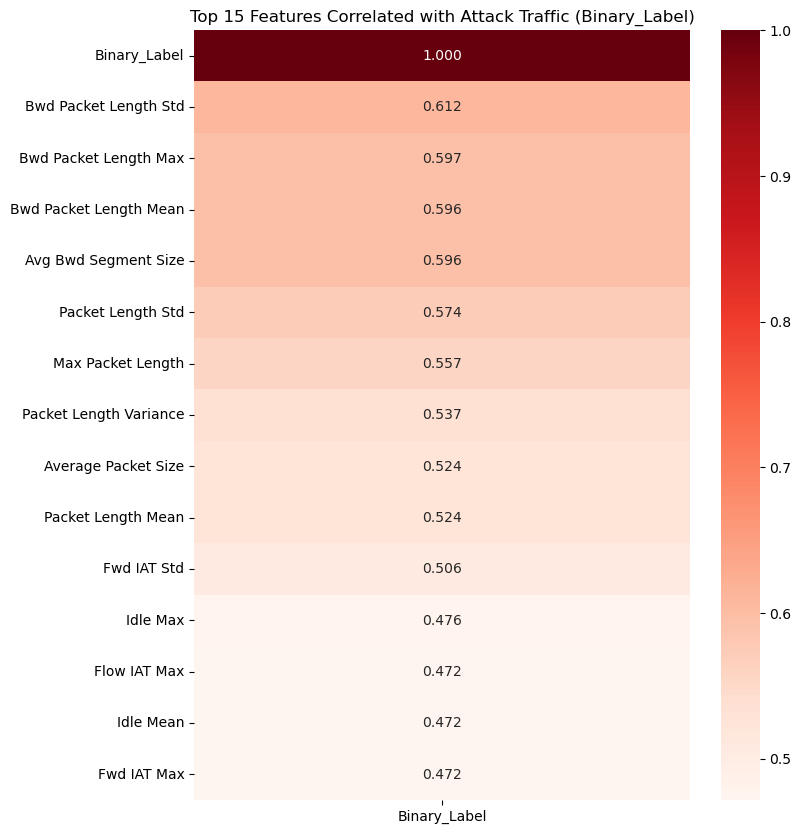

In [33]:
plt.figure(figsize=(8, 10))
# dropping string and multi class target to calculate correlation properly
binary_corr = df_data.drop(columns=['Label', 'Label_Encoded']).corr()[['Binary_Label']].sort_values(by='Binary_Label', ascending=False)
sns.heatmap(binary_corr.head(15), annot=True, cmap='Reds', fmt='.3f')
plt.title("Top 15 Features Correlated with Attack Traffic (Binary_Label)")
plt.show()

In [34]:
# df_data.drop(columns=['RST Flag Count'] , inplace=True , errors='ignore')

Bug fix: the redundant columns found above (correlation > 0.95, e.g. the duplicate `Fwd Header Length.1`) were identified but never actually dropped. Dropping them now, right before modeling, so the earlier EDA plots still use the full feature set.

In [35]:
# df_data.drop(columns=to_drop, inplace=True, errors='ignore')
# print("Shape after dropping redundant (>0.95 correlated) columns:", df_data.shape)

Feature & Target Split

In [36]:
X = df_data.drop(columns=['Label', 'Label_Encoded', 'Binary_Label'], errors='ignore')
y = df_data['Binary_Label']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [37]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
X_train = pd.DataFrame(selector.fit_transform(X_train),columns=X_train.columns[selector.get_support()],index=X_train.index)
X_test = X_test[X_train.columns]

In [ ]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

In [39]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X_train.columns
).sort_values(ascending=False)

selected_features = mi_scores.head(40).index

X_train = X_train[selected_features]
X_test = X_test[selected_features]

In [40]:
# X = df_data.drop(columns=['Label', 'Label_Encoded', 'Binary_Label'])
# y = df_data['Binary_Label']

In [41]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [42]:
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (499175, 40), X_test shape: (124794, 40)


Feature Scaling
- Fit on train set, transform both train and test to prevent data leakage


In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Final Cleaned Data Overview

In [49]:
print("Final shape:", df_data.shape)
df_data.head()

Final shape: (623969, 72)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Port_Category_Registered,Port_Category_Well_Known,Label_Encoded,Binary_Label
0,59821.00,1.00,1.00,56.00,84.00,56.00,56.00,56.00,0.00,84.00,...,0.00,0.00,0.00,0.00,0.00,BENIGN,False,True,0,0
1,60381.00,1.00,1.00,46.00,233.00,46.00,46.00,46.00,0.00,233.00,...,0.00,0.00,0.00,0.00,0.00,BENIGN,False,True,0,0
2,418.00,2.00,2.00,352.00,358.00,176.00,176.00,176.00,0.00,179.00,...,0.00,0.00,0.00,0.00,0.00,BENIGN,False,True,0,0
3,76165.00,10.00,8.00,495.00,5559.00,191.00,0.00,49.50,77.45,1460.00,...,0.00,0.00,0.00,0.00,0.00,BENIGN,False,True,0,0
4,217.00,3.00,0.00,49.00,0.00,37.00,6.00,16.33,17.90,0.00,...,0.00,0.00,0.00,0.00,0.00,BENIGN,False,True,0,0


## Preprcessing


In [50]:
# # no need to scale dummy(0,1) features
# dummy_cols = [col for col in X.columns if col.startswith('Port_Category_')]
# numeric_cols = [col for col in X.columns if col not in dummy_cols]

# scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# print("Train shape:", X_train_scaled.shape)
# print("Test shape:", X_test_scaled.shape)

#### The data is imbalanced (BENIGN dominates), so we compute class weights


#### Imbalance Handling — Dynamic Function
The dataset is highly imbalanced (BENIGN dominates). Instead of hard-coding one fix, we define a single dynamic function `handle_imbalance()` where we can just switch the `IMBALANCE_STRATEGY` variable between `'class_weight'`, `'smote'`, `'undersample'`, or `'none'`. Every cell after this (baseline model, models dictionary, training) reads from the result of this function automatically, so switching strategy does not require touching any other cell.


In [52]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

def handle_imbalance(X_train, y_train, strategy="class_weight", random_state=42, sampling_strategy="auto"):
 
    strategy = strategy.lower()
    class_weight_dict = None
    X_train_out, y_train_out = X_train, y_train

    if strategy == "none":
        print("Imbalance strategy: none -> using the original training data as-is.")

    elif strategy == "class_weight":
        classes = np.unique(y_train)
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
        class_weight_dict = dict(zip(classes, weights))
        print("Imbalance strategy: class_weight")
        print("Class weights:", class_weight_dict)

    elif strategy == "smote":
        from imblearn.over_sampling import SMOTE
        print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
        smote = SMOTE(sampling_strategy=sampling_strategy, random_state=random_state)
        X_train_out, y_train_out = smote.fit_resample(X_train, y_train)
        print("After  SMOTE:", dict(zip(*np.unique(y_train_out, return_counts=True))))

    elif strategy == "undersample":
        from imblearn.under_sampling import RandomUnderSampler
        print("Before Undersampling:", dict(zip(*np.unique(y_train, return_counts=True))))
        rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=random_state)
        X_train_out, y_train_out = rus.fit_resample(X_train, y_train)
        print("After  Undersampling:", dict(zip(*np.unique(y_train_out, return_counts=True))))

    else:
        raise ValueError(
            f"Unknown imbalance strategy: '{strategy}'. "
            "Choose one of: 'none', 'class_weight', 'smote', 'undersample'."
        )

    return X_train_out, y_train_out, class_weight_dict


In [51]:
# vvv Change ONLY this line to switch the imbalance-handling strategy vvv
IMBALANCE_STRATEGY = "class_weight"   # options: "none", "class_weight", "smote", "undersample"
# ^^^ Everything below (baseline model, models dict, training) adapts automatically ^^^

X_train_final, y_train_final, class_weight_dict = handle_imbalance(
    X_train_scaled, y_train, strategy=IMBALANCE_STRATEGY, random_state=42
)

print("\nX_train_final shape:", X_train_final.shape, "| y_train_final shape:", y_train_final.shape)


Imbalance strategy: class_weight
Class weights: {np.int64(0): np.float64(0.6027751748521968), np.int64(1): np.float64(2.932494037198482)}

X_train_final shape: (499175, 40) | y_train_final shape: (499175,)


#### Try a simple model first (Logistic Regression) to get a baseline we can compare future models against


## Modeling

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay
import time

#### Evaluation function used for any model type

In [54]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Train_Time_sec": train_time
    }

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", results["ROC_AUC"])

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return results, model

#### Function to run and compare many models at once

In [56]:
def run_models(models_dict, X_train, y_train, X_test, y_test):
    all_results = []
    trained_models = {}

    for name, model in models_dict.items():
        results, fitted_model = evaluate_model(name, model, X_train, y_train, X_test, y_test)
        all_results.append(results)
        trained_models[name] = fitted_model

    results_df = pd.DataFrame(all_results).sort_values(by="F1", ascending=False).reset_index(drop=True)
    return results_df, trained_models

#### Function for hyperparameter tuning any model with GridSearchCV

In [55]:
def tune_model(model, param_grid, X_train, y_train, cv=3, scoring='f1'):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring=scoring, n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    print("Best params:", grid.best_params_)
    print("Best score:", grid.best_score_)

    return grid.best_estimator_

#### Dictionary of different model types to compare

In [59]:
from sklearn.linear_model import LogisticRegression
models = {
    "Logistic Regression": LogisticRegression(class_weight=class_weight_dict, max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight=class_weight_dict, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight=class_weight_dict, n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}

try:
    from xgboost import XGBClassifier
    xgb_params = dict(eval_metric='logloss', random_state=42, n_jobs=-1)
    if class_weight_dict is not None:
        # XGBoost (binary) doesn't accept a class_weight dict, it uses scale_pos_weight instead
        xgb_params['scale_pos_weight'] = class_weight_dict[1] / class_weight_dict[0]
    models["XGBoost"] = XGBClassifier(**xgb_params)
except ImportError:
    pass

try:
    from lightgbm import LGBMClassifier
    lgbm_params = dict(random_state=42, n_jobs=-1)
    if class_weight_dict is not None:
        lgbm_params['class_weight'] = class_weight_dict
    models["LightGBM"] = LGBMClassifier(**lgbm_params)
except ImportError:
    pass


#### Run all models and compare results


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.99      0.94      0.96    103516
           1       0.75      0.96      0.84     21278

    accuracy                           0.94    124794
   macro avg       0.87      0.95      0.90    124794
weighted avg       0.95      0.94      0.94    124794

ROC-AUC: 0.9836616417952605


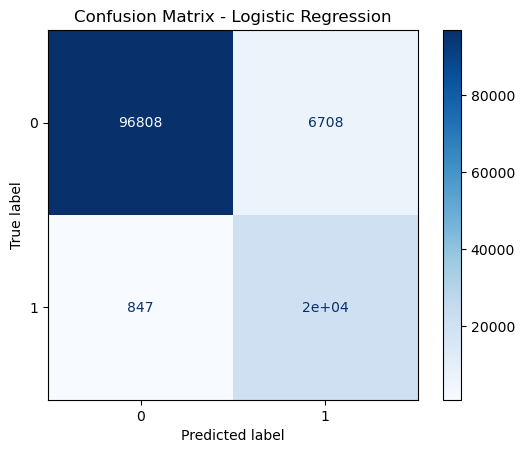


===== Decision Tree =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103516
           1       0.99      1.00      1.00     21278

    accuracy                           1.00    124794
   macro avg       1.00      1.00      1.00    124794
weighted avg       1.00      1.00      1.00    124794

ROC-AUC: 0.9977620637409275


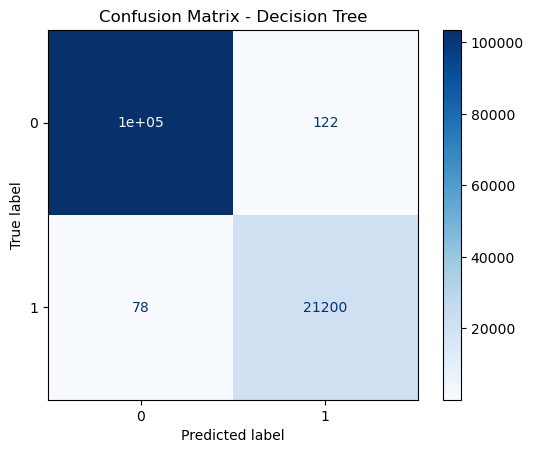


===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103516
           1       1.00      1.00      1.00     21278

    accuracy                           1.00    124794
   macro avg       1.00      1.00      1.00    124794
weighted avg       1.00      1.00      1.00    124794

ROC-AUC: 0.9998300793539875


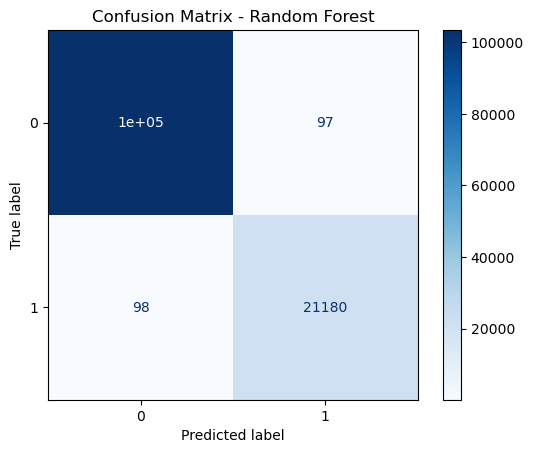


===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103516
           1       0.99      0.98      0.98     21278

    accuracy                           0.99    124794
   macro avg       0.99      0.99      0.99    124794
weighted avg       0.99      0.99      0.99    124794

ROC-AUC: 0.9992738834853423


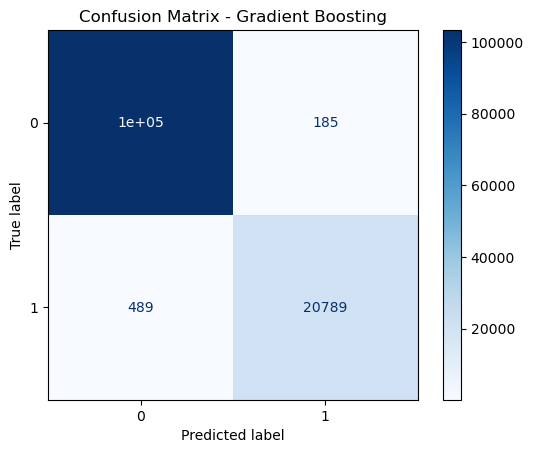


===== AdaBoost =====
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    103516
           1       0.98      0.93      0.95     21278

    accuracy                           0.98    124794
   macro avg       0.98      0.96      0.97    124794
weighted avg       0.98      0.98      0.98    124794

ROC-AUC: 0.9962314102333583


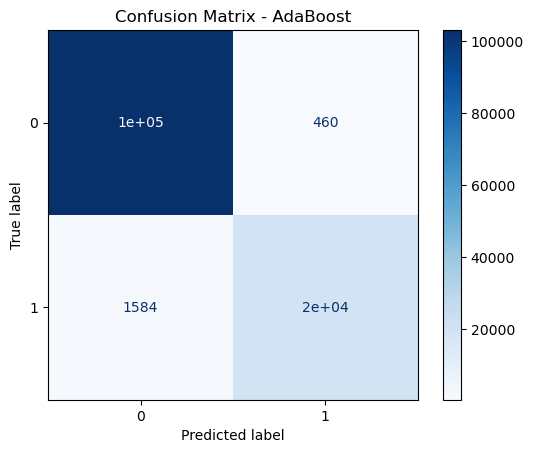


===== KNN =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103516
           1       0.99      0.99      0.99     21278

    accuracy                           1.00    124794
   macro avg       1.00      1.00      1.00    124794
weighted avg       1.00      1.00      1.00    124794

ROC-AUC: 0.998660303512321


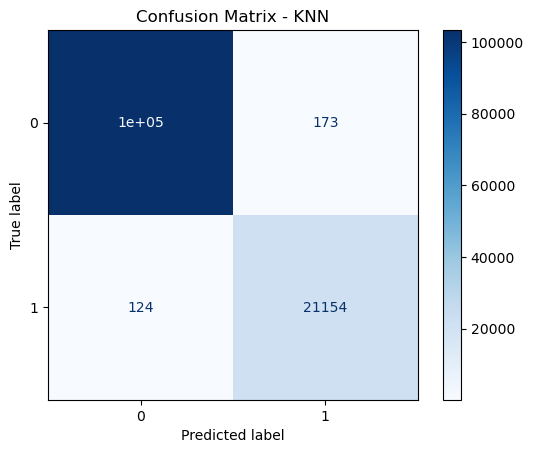


===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.92      0.92      0.92    103516
           1       0.62      0.61      0.62     21278

    accuracy                           0.87    124794
   macro avg       0.77      0.77      0.77    124794
weighted avg       0.87      0.87      0.87    124794

ROC-AUC: 0.8949599609908493


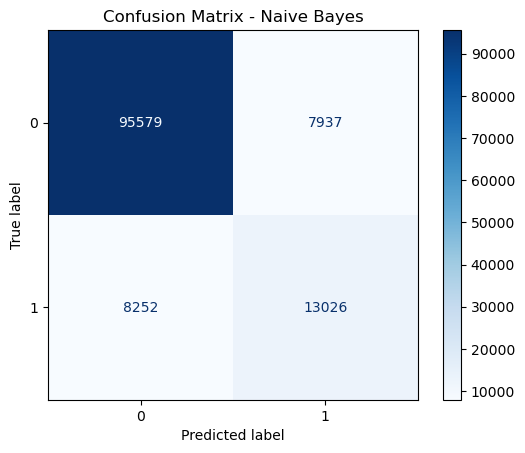


===== XGBoost =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103516
           1       0.99      1.00      1.00     21278

    accuracy                           1.00    124794
   macro avg       1.00      1.00      1.00    124794
weighted avg       1.00      1.00      1.00    124794

ROC-AUC: 0.9999551503237711


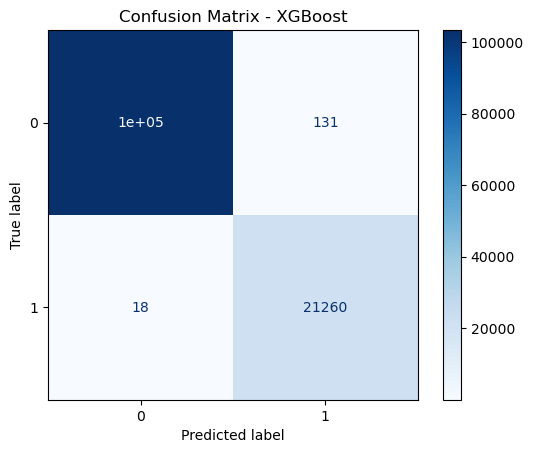

[LightGBM] [Info] Number of positive: 85111, number of negative: 414064
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030927 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8466
[LightGBM] [Info] Number of data points in the train set: 499175, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

===== LightGBM =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103516
           1       0.99      1.00      1.00     21278

    accuracy                           1.00    124794
   macro avg       1.00      1.00      1.00    124794
weighted avg       1.00      1.00      1.00    124794

ROC-AUC: 0.9999422551877564


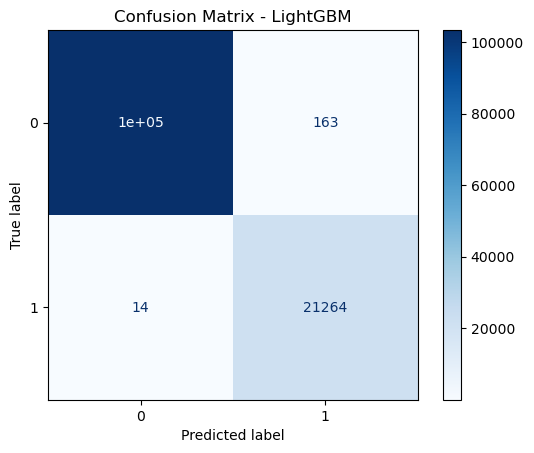

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time_sec
0,XGBoost,1.00,0.99,1.00,1.00,1.00,4.20
1,LightGBM,1.00,0.99,1.00,1.00,1.00,5.17
2,Random Forest,1.00,1.00,1.00,1.00,1.00,73.57
3,Decision Tree,1.00,0.99,1.00,1.00,1.00,15.51
4,KNN,1.00,0.99,0.99,0.99,1.00,0.06
5,Gradient Boosting,0.99,0.99,0.98,0.98,1.00,429.28
6,AdaBoost,0.98,0.98,0.93,0.95,1.00,75.14
7,Logistic Regression,0.94,0.75,0.96,0.84,0.98,10.52
8,Naive Bayes,0.87,0.62,0.61,0.62,0.89,0.25


In [60]:
results_df, trained_models = run_models(models, X_train_final, y_train_final, X_test_scaled, y_test)
results_df


#### Visual comparison of all models across metrics

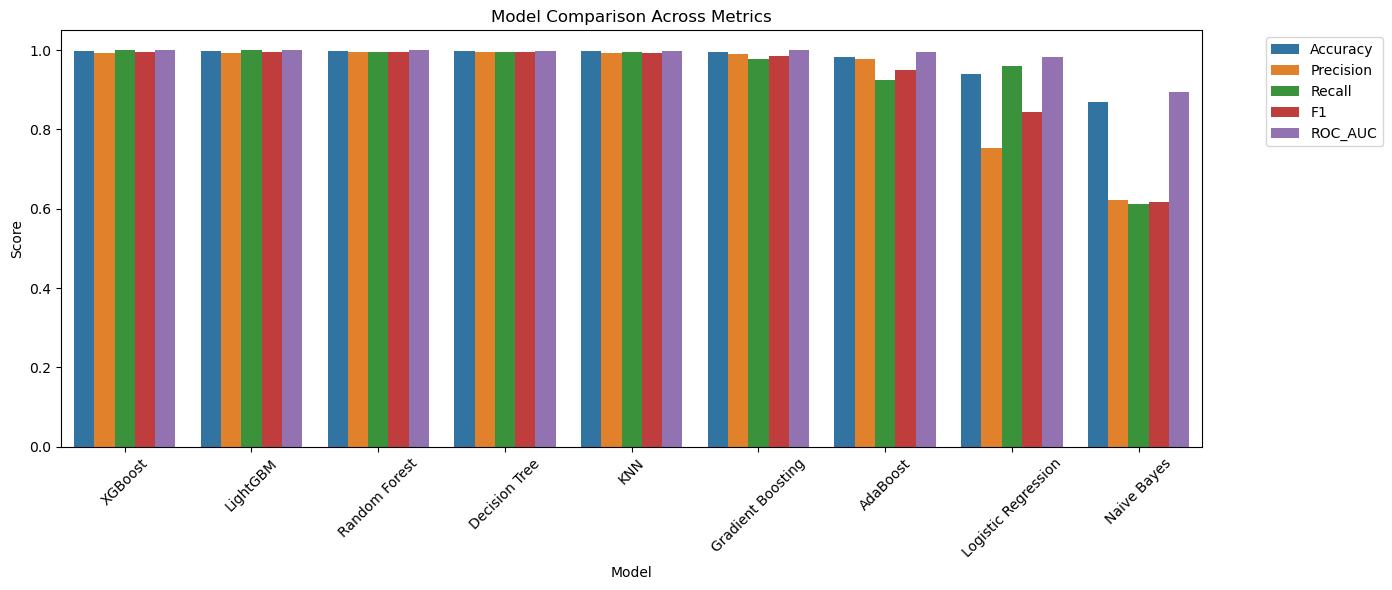

In [61]:
metrics_melted = results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"])

plt.figure(figsize=(14, 6))
sns.barplot(data=metrics_melted, x="Model", y="value", hue="variable")
plt.xticks(rotation=45)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()